## Time Series Analysis - Forecasting Crypto with LSTM (Long Short-Term Memory Networks)

### 1. Loading the data

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import warnings

# ignore warnings
warnings.filterwarnings("ignore")

# Step 1: Pull Crypto data for the past 1 year.

crypto_symbol = "BTC-USD"
prediction_ahead = 15
btc_data = yf.download(crypto_symbol, period = '1y', interval = '1d')
btc_data = btc_data[['Close']].dropna()
btc_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,BTC-USD
Date,
2025-02-23,96273.921875
2025-02-24,91418.171875
2025-02-25,88736.171875
2025-02-26,84347.023438
2025-02-27,84704.226562


### 1.2. Data Preprocessing

LSTMs expect input data in the shape: [samples, time steps, features].
* samples: Number of sequences (rows in X).
* time steps: Lenght of each sequence (e.g., 60).
* features: Number of features at each time step (e.g., 1).

### EXAMPLE:
Input Dataset-

data = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], time step = 3

Sequence (X) : Target (Y) | [1, 2, 3] : 4, [2, 3, 4] : 5, [3, 4, 5] : 6, ....

In [2]:
# Prepare data for LSTM
scaler = MinMaxScaler(feature_range = (0,1))
scaled_data = scaler.fit_transform(btc_data)

# Correct split for training and testing datasets
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

def create_dataset(data, time_step = 1):
    x, y = [], []
    for i in range(len(data) - time_step):
        x.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(x), np.array(y)

# Use 80% of the total data for training and 20% for testing.
time_step = 60
x_train, y_train = create_dataset(scaled_data[:train_size], time_step)
x_test, y_test = create_dataset(scaled_data[train_size - time_step:], time_step)

# Reshape input to be [samples, time_steps, features]
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)

In [3]:
y_train[0:10]  # or x_train[0:10]

array([0.50348881, 0.5160061 , 0.51482045, 0.50044366, 0.52016804,
       0.50898422, 0.50773561, 0.54456087, 0.55129305, 0.53488263])

### 2. Build LSTM Model

General Overview:
* LSTMs are a type of Recurrent Neural Network (RNN) designed to process sequential data, such as time series, text, or speech.
* They overcome the vanishing gradient problem of traditional RNNs, enabling them to capture long-term dependencies in seqences.
* LSTMs are widely used in tasks like language modeling, translation, speech recognition, and time-series forecasting.

In [4]:
# Build LSTM Model
model = Sequential()
model.add(LSTM(50, return_sequences = True, input_shape = (time_step, 1)))
model.add(LSTM(50, return_sequences = False))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, batch_size = 1, epochs = 5, verbose = 1)

# Make predictions
train_predictions = model.predict(x_train)
test_predictions = model.predict(x_test)

# Inverse transform predictions and actual values
train_predictions = scaler.inverse_transform(train_predictions)
y_train = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predictions = scaler.inverse_transform(test_predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

Epoch 1/5


2026-02-23 17:26:24.865592: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-02-23 17:26:24.865636: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-23 17:26:24.865642: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-02-23 17:26:24.865662: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-23 17:26:24.865679: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-02-23 17:26:25.211681: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0188
Epoch 2/5
232/232 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0064
Epoch 3/5
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0043
Epoch 4/5
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0057
Epoch 5/5
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0038
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


### 3. Forecasting Ahead

In [5]:
# Forecasting for future days
last_60_days = scaled_data[-time_step:]
future_input = last_60_days.reshape(1, time_step, 1)
future_forecast = []
for _ in range(prediction_ahead):
    next_pred = model.predict(future_input)[0, 0]
    future_forecast.append(next_pred)
    next_input = np.append(future_input[0, 1:], [[next_pred]], axis = 0)
    future_input = next_input.reshape(1, time_step, 1)

future_forecast = scaler.inverse_transform(np.array(future_forecast).reshape(-1, 1))

# Latest close price and Last predicted price
latest_close_price = float(btc_data['Close'].iloc[-1])
last_predicted_price = float(future_forecast[-1])

# Print metrics
print(f"Latest Close Price: ${latest_close_price:,.2f}")
print(f"Price After {prediction_ahead} Days: ${last_predicted_price:,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Latest Close Price: $64,863.36
Price After 15 Days: $80,948.01


### 4. Plot the results

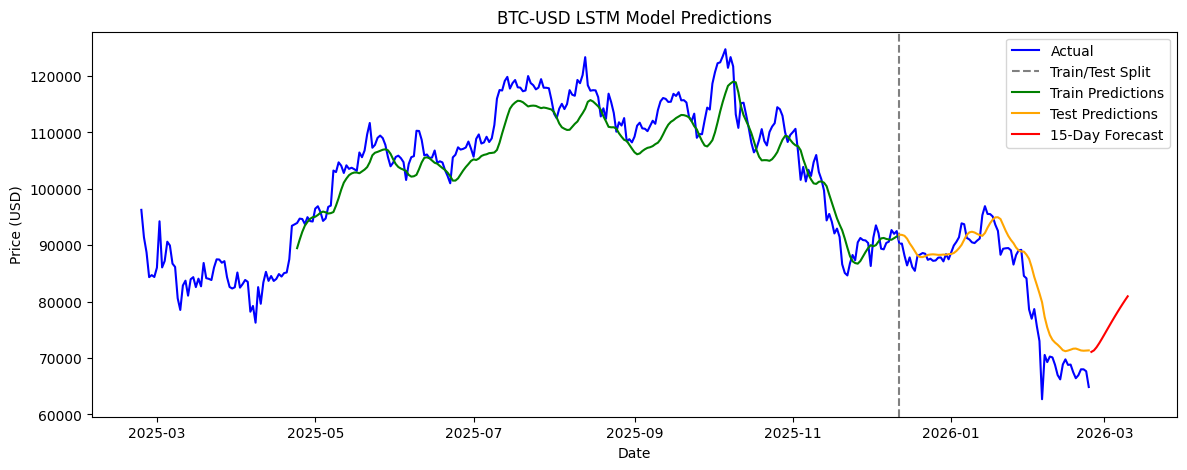

In [6]:
# Plot the results
plt.figure(figsize = (14, 5))
plt.plot(btc_data.index, btc_data['Close'], label = 'Actual', color = 'blue')
plt.axvline(x = btc_data.index[train_size], color = 'gray', linestyle = '--', label = 'Train/Test Split')

# Train/Test and Predictions
train_range = btc_data.index[time_step:train_size]
test_range = btc_data.index[train_size:train_size + len(test_predictions)]
plt.plot(train_range, train_predictions[:len(train_range)], label = 'Train Predictions', color = 'green')
plt.plot(test_range, test_predictions[:len(test_range)], label = 'Test Predictions', color = 'orange')

# Future Predictions
future_index = pd.date_range(start = btc_data.index[-1], periods = prediction_ahead + 1, freq = 'D')[1:]
plt.plot(future_index, future_forecast, label = f'{prediction_ahead}-Day Forecast', color = 'red')

plt.title(f'{crypto_symbol} LSTM Model Predictions')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

### 5. Running it all together

[*********************100%***********************]  1 of 1 completed

Epoch 1/5


232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0190
Epoch 2/5
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0067
Epoch 3/5
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0042
Epoch 4/5
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0045
Epoch 5/5
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0035
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Latest Close Price: $64,863.3

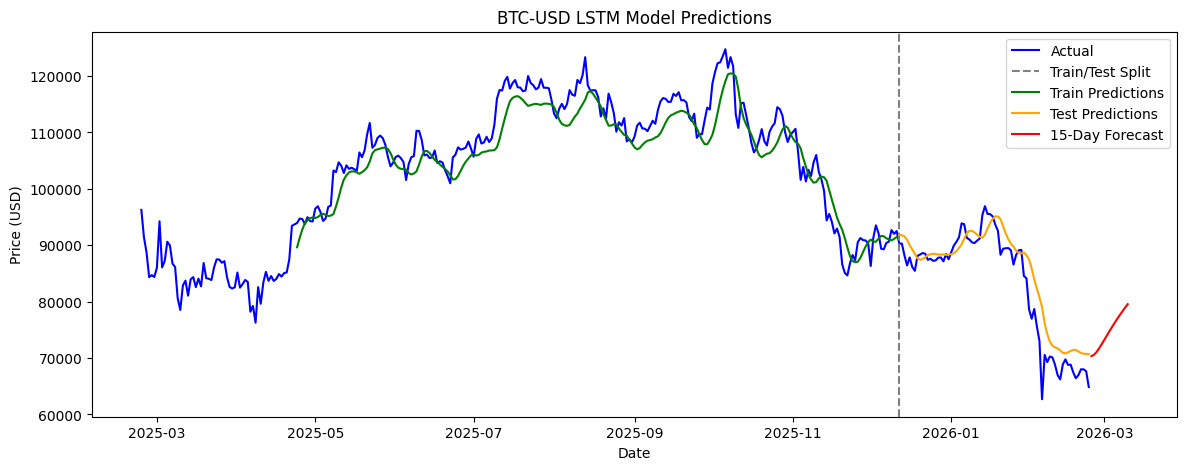

In [7]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import warnings

# ignore warnings
warnings.filterwarnings("ignore")

# Step 1: Pull Crypto data for the past 1 year.

crypto_symbol = "BTC-USD"
prediction_ahead = 15
btc_data = yf.download(crypto_symbol, period = '1y', interval = '1d')
btc_data = btc_data[['Close']].dropna()
btc_data.head()

# Prepare data for LSTM
scaler = MinMaxScaler(feature_range = (0,1))
scaled_data = scaler.fit_transform(btc_data)

# Correct split for training and testing datasets
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

def create_dataset(data, time_step = 1):
    x, y = [], []
    for i in range(len(data) - time_step):
        x.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(x), np.array(y)

# Use 80% of the total data for training and 20% for testing.
time_step = 60
x_train, y_train = create_dataset(scaled_data[:train_size], time_step)
x_test, y_test = create_dataset(scaled_data[train_size - time_step:], time_step)

# Reshape input to be [samples, time_steps, features]
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)

y_train[0:10]  # or x_train[0:10]

# Build LSTM Model
model = Sequential()
model.add(LSTM(50, return_sequences = True, input_shape = (time_step, 1)))
model.add(LSTM(50, return_sequences = False))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, batch_size = 1, epochs = 5, verbose = 1)

# Make predictions
train_predictions = model.predict(x_train)
test_predictions = model.predict(x_test)

# Inverse transform predictions and actual values
train_predictions = scaler.inverse_transform(train_predictions)
y_train = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predictions = scaler.inverse_transform(test_predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Forecasting for future days
last_60_days = scaled_data[-time_step:]
future_input = last_60_days.reshape(1, time_step, 1)
future_forecast = []
for _ in range(prediction_ahead):
    next_pred = model.predict(future_input)[0, 0]
    future_forecast.append(next_pred)
    next_input = np.append(future_input[0, 1:], [[next_pred]], axis = 0)
    future_input = next_input.reshape(1, time_step, 1)

future_forecast = scaler.inverse_transform(np.array(future_forecast).reshape(-1, 1))

# Latest close price and Last predicted price
latest_close_price = float(btc_data['Close'].iloc[-1])
last_predicted_price = float(future_forecast[-1])

# Print metrics
print(f"Latest Close Price: ${latest_close_price:,.2f}")
print(f"Price After {prediction_ahead} Days: ${last_predicted_price:,.2f}")

# Plot the results
plt.figure(figsize = (14, 5))
plt.plot(btc_data.index, btc_data['Close'], label = 'Actual', color = 'blue')
plt.axvline(x = btc_data.index[train_size], color = 'gray', linestyle = '--', label = 'Train/Test Split')

# Train/Test and Predictions
train_range = btc_data.index[time_step:train_size]
test_range = btc_data.index[train_size:train_size + len(test_predictions)]
plt.plot(train_range, train_predictions[:len(train_range)], label = 'Train Predictions', color = 'green')
plt.plot(test_range, test_predictions[:len(test_range)], label = 'Test Predictions', color = 'orange')

# Future Predictions
future_index = pd.date_range(start = btc_data.index[-1], periods = prediction_ahead + 1, freq = 'D')[1:]
plt.plot(future_index, future_forecast, label = f'{prediction_ahead}-Day Forecast', color = 'red')

plt.title(f'{crypto_symbol} LSTM Model Predictions')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

### 6. Streamlit Application

In [8]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import warnings
import streamlit as st
from PIL import Image

# ignore warnings
warnings.filterwarnings("ignore")

# Streamlit configuration
st.set_page_config(layout = "wide")
st.markdown("<style>.main {padding-top: 0px;}</style>", unsafe_allow_html = True)

# Add images
st.sidebar.image("Pic1.png", use_column_width = True)
st.image("Pic2.png", use_column_width = True)

# Add main title
st.markdown("<h1 style = 'text-align: center; margin-top: -20px; '>LSTM Forecasting Model</h1>", unsafe_allow_html = True)

# Sidebar inputs
st.sidebar.header("Model Parameters")
crypto_symbol = st.sidebar.text_input("Cryptocurrency Symbol", "BTC-USD")
prediction_ahead = st.sidebar.number_input("Prediction Days Ahead", min_value = 1, max_value = 30, value = 15, step = 1)
if st.sidebar.button("Predict"):
    # Step 1: Pull Crypto data for the past 1 year.
    
    crypto_symbol = "BTC-USD"
    prediction_ahead = 15
    btc_data = yf.download(crypto_symbol, period = '1y', interval = '1d')
    btc_data = btc_data[['Close']].dropna()
    btc_data.head()
    
    # Prepare data for LSTM
    scaler = MinMaxScaler(feature_range = (0,1))
    scaled_data = scaler.fit_transform(btc_data)
    
    # Correct split for training and testing datasets
    train_size = int(len(scaled_data) * 0.8)
    train_data = scaled_data[:train_size]
    test_data = scaled_data[train_size:]
    
    def create_dataset(data, time_step = 1):
        x, y = [], []
        for i in range(len(data) - time_step):
            x.append(data[i:(i + time_step), 0])
            y.append(data[i + time_step, 0])
        return np.array(x), np.array(y)
    
    # Use 80% of the total data for training and 20% for testing.
    time_step = 60
    x_train, y_train = create_dataset(scaled_data[:train_size], time_step)
    x_test, y_test = create_dataset(scaled_data[train_size - time_step:], time_step)
    
    # Reshape input to be [samples, time_steps, features]
    x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
    x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)
    
    y_train[0:10]  # or x_train[0:10]
    
    # Build LSTM Model
    model = Sequential()
    model.add(LSTM(50, return_sequences = True, input_shape = (time_step, 1)))
    model.add(LSTM(50, return_sequences = False))
    model.add(Dense(25))
    model.add(Dense(1))
    
    model.compile(optimizer = 'adam', loss = 'mean_squared_error')
    model.fit(x_train, y_train, batch_size = 1, epochs = 5, verbose = 1)
    
    # Make predictions
    train_predictions = model.predict(x_train)
    test_predictions = model.predict(x_test)
    
    # Inverse transform predictions and actual values
    train_predictions = scaler.inverse_transform(train_predictions)
    y_train = scaler.inverse_transform(y_train.reshape(-1, 1))
    test_predictions = scaler.inverse_transform(test_predictions)
    y_test = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    # Forecasting for future days
    last_60_days = scaled_data[-time_step:]
    future_input = last_60_days.reshape(1, time_step, 1)
    future_forecast = []
    for _ in range(prediction_ahead):
        next_pred = model.predict(future_input)[0, 0]
        future_forecast.append(next_pred)
        next_input = np.append(future_input[0, 1:], [[next_pred]], axis = 0)
        future_input = next_input.reshape(1, time_step, 1)
    
    future_forecast = scaler.inverse_transform(np.array(future_forecast).reshape(-1, 1))
    
    # Latest close price and Last predicted price
    latest_close_price = float(btc_data['Close'].iloc[-1])
    last_predicted_price = float(future_forecast[-1])

    # Centered layout for metrics
    col1, col2, col3 = st.columns([1, 2, 1])
    with col2:
        st.markdown(
            f"""
            <div style = "display: flex; justify-content: space-around;">
                <div style = "background-color: #d5f5d5; color: black; padding: 10px; border-radius: 10px; text-align: center;">
                    <h3>Latest Close Price</h3>
                    <p style = "font-size: 20px;">${latest_close_price:,.2f}</p>
                </div>
                <div style = "background-color: #d5f5d5; color: black; padding: 10px; border-radius: 10px; text-align: center;">
                    <h3>Price After {prediction_ahead} Days</h3>
                    <p style = "font-size: 20px;">${last_predicted_price:,.2f}</p>
                </div>
            </ div>
            """,
            unsafe_allow_html = True,
        )

    # Plot the results
    plt.figure(figsize = (14, 5))
    plt.plot(btc_data.index, btc_data['Close'], label = 'Actual', color = 'blue')
    plt.axvline(x = btc_data.index[train_size], color = 'gray', linestyle = '--', label = 'Train/Test Split')
    
    # Train/Test and Predictions
    train_range = btc_data.index[time_step:train_size]
    test_range = btc_data.index[train_size:train_size + len(test_predictions)]
    plt.plot(train_range, train_predictions[:len(train_range)], label = 'Train Predictions', color = 'green')
    plt.plot(test_range, test_predictions[:len(test_range)], label = 'Test Predictions', color = 'orange')
    
    # Future Predictions
    future_index = pd.date_range(start = btc_data.index[-1], periods = prediction_ahead + 1, freq = 'D')[1:]
    plt.plot(future_index, future_forecast, label = f'{prediction_ahead}-Day Forecast', color = 'red')
    
    plt.title(f'{crypto_symbol} LSTM Model Predictions')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.show()

# Streamlit run LSTM_V2.py

2026-02-23 17:26:55.464 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-23 17:26:55.464 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-23 17:26:55.565 
  command:

    streamlit run /opt/anaconda3/envs/lstm-venv/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-02-23 17:26:55.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-23 17:26:55.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-23 17:26:55.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-23 17:26:55.566 Thread 'MainThread': missing ScriptRunContext! This warning can be i